In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ADV QC
- despiking
- clock drift correction
- rotation matrix 
- trimto in water start/end
- configured salinity
- atmospheric pressure corrections (maybe important for storm surge?)

### 1. Trim to in water start.end

- use p < 3 dbars, plus a buffer of 10 seconds before and after to trim the data to when the instrument is in water.
- in air pressure at the start will give the original pressure-sensor offset. **However** due to low pressure from moving hurricanes, the atmospheric pressure may have to be adjusted during mid deployment. 
- Sound speed/salinity corrections 



In [3]:
data_path = "/Users/isidorarojas/Desktop/DIRECTORY/2026/4EWA/data/processed"
VC2 = xr.open_dataset(data_path + '/VC2.nc')

In [4]:
VC2

<xarray.Dataset> Size: 503MB
Dimensions:              (x: 3, x*: 3, time: 10711034, beam: 3, earth: 3,
                          inst: 3)
Coordinates:
  * x                    (x) int64 24B 1 2 3
  * x*                   (x*) int64 24B 1 2 3
  * time                 (time) datetime64[ns] 86MB 2026-07-18T22:59:02.99998...
  * beam                 (beam) int64 24B 1 2 3
  * earth                (earth) <U1 12B 'E' 'N' 'U'
  * inst                 (inst) <U1 12B 'X' 'Y' 'Z'
Data variables:
    beam2inst_orientmat  (x, x*) float32 36B ...
    heading              (time) float32 43MB ...
    pitch                (time) float32 43MB ...
    roll                 (time) float32 43MB ...
    temp                 (time) float32 43MB ...
    orientation_down     (time) bool 11MB ...
    amp                  (beam, time) uint8 32MB ...
    corr                 (beam, time) uint8 32MB ...
    p                    (time) float32 43MB ...
    u                    (time) float32 43MB ...
    v                    (time) float32 43MB ...
    w                    (time) float32 43MB ...
Attributes: (12/59)
    inst_make:                   Nortek
    inst_model:                  Vector
    inst_type:                   ADV
    rotate_vars:                 vel
    n_beams:                     3
    profile_mode:                continuous
    ...                          ...
    status_code_counts:          0: 5355593; 213: 2; 221: 10; 237: 30; 241: 6...
    orientation_down_constant:   True
    dropped_variables:           orientmat, batt, c_sound, error, status
    complex_vars:                []
    heading_kvh_magnetic_deg:    343.2
    heading_notes:               GoPro verified from deployment

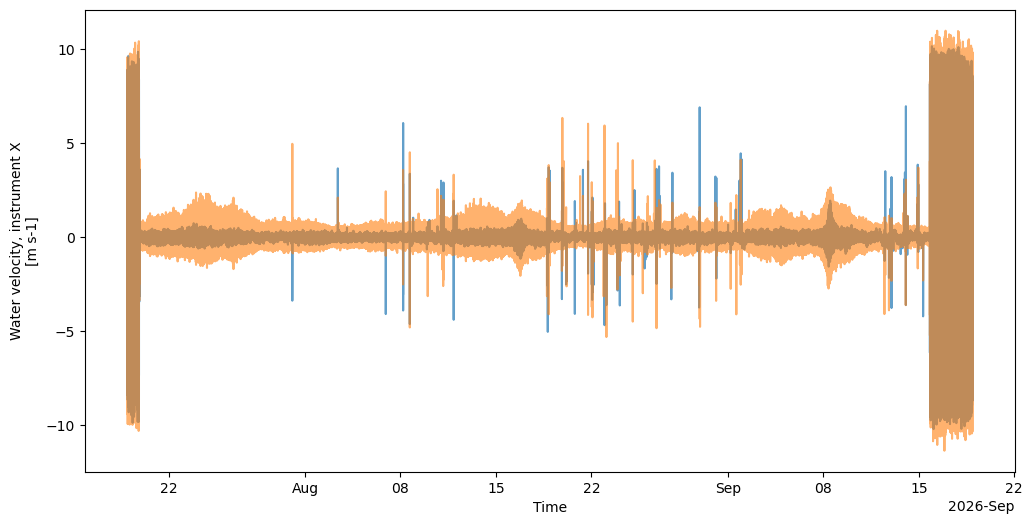

In [9]:
plt.figure(figsize=(12, 6))
VC2['v'].plot(alpha=0.7)
VC2['u'].plot(alpha=0.6)

### Clock Drift Correction
 - The standard approach is a linear drift from 0 at start to the measured drift at recovery, as linspace over the record. Check
   the CSV sign convention: negative means the sensor clock is slow, so corrected $ time = t − drift·(fraction elapsed)$ only when that sign is respected.

 - With no measured Vector drift:
   - Tide cross-correlation (NOAA Honolulu 1612340) catches time-zone and
     hour-scale
     offsets. Derive the lag sign as in PIPELINE_NOTES.md ("recovered filename
     clock is
     LOCAL time"). A lag scan alone can't tell ±. It does not resolve seconds.
   - VC2 vs ADCP are co-located (same lat/lon). Wave-band p–p cross-correlation
     gives
     seconds-level sync for VC2 against the ADCP, which has a known drift of −6
     s.
   - Other pairs (Vector vs nearby P-sensor): lag = propagation time + drift,
     so drift
     can only be bounded. Split lags over time: a drift trend across the
     deployment is
     separable from a constant propagation lag.


### Beam Quality masks
 - Correlation: the lab uses a minimum beam correlation below 70% → NaN (Nortek
   recommendation) [lab]. Also check low amplitude/SNR (burial, fouling, out of
   water).
   Watch for progressive correlation loss, which can be biofouling in warm
   water (CAT21A note
   in PIPELINE_NOTES.md) [lab].
 - Gate per channel, not per row. The lab's 2026-07 channel-decoupling rework
   lets pressure
   and velocity fail independently (shared/../puv_channel_qc.m,
   docs/OUTSTANDING_channel_decoupling.md) [lab].
 - Report the % flagged per sensor and per hour, and plot it against time and
   Hs.

### 4. Despiking
 - Order: despike in the instrument frame, before rotation. Rotation smears a spike on one beam into all components.
 - Method: Goring & Nikora (2002) phase-space thresholding, modified by Wahl (2003). Mori, Suzuki & Kakuno (2007) is the variant for bubbly/wave conditions. dolfyn 1.3.0 has dolfyn.adv.clean.GN2002, spike_thresh, range_limit, clean_fill (verified present).
 - At 2 Hz in waves, GN2002's "universal threshold" assumes a spiky turbulence signal sampled fast. Real orbital-velocity crests can be flagged. Apply it to a residual (detrended or high-passed about the wave-band signal, or per short window), or tune the threshold. Inspect flagged points overlaid on raw data during the largest-wave hours.
 - Replace only short runs (interpolate ≲ a few samples). Leave longer gaps as NaN. Record % replaced per segment; the lab drops segments with >10% NaN before spectra (nanMaxFrac).
 - Surf-zone ADV QC context: Elgar, Raubenheimer & Guza (2001, 2005) and Feddersen (2010).

 ### 5. Tilt / attitude
 - The internal sensors describe the canister, not the head. These are
   cable-head Vectors and the canister lies nearly horizontal (VB1 pitch/roll about ±165°). dolfyn's orientmat and orientation_down bit reflect the housing, so they are not valid for rotating head-frame velocity. Check the orientation_down counts from the slim step.
 - dolfyn: set_inst2head_rotmat exists for cable heads (verified in 1.3.0). Without a measured head attitude, assume the head is vertical 
 - Use canister tilt as a motion detector, not a correction: a rolling std of pitch/roll (the lab flags >2° over 60 s), and heading steps. The VD2 compass step near 09-08 means the frame or head moved. Split the record there and check it.
 - Loose heads (VB1, VE1, VE2): the head could rotate independently of the
   canister, so the compass can't show it. Detect from the data: track std(w)/std(u) (tilt leakage) and the wave/current principal-axis direction per day. A step means head motion.


### 6. Rotation to earth/shore-normal 

- Rotate XYZ coords to earth coordinates usingg KVH magnetic heading + declination. 
- Then rotate to shore-normal coordinates
 - Verify the heading physically. This is how the lab caught its 180° errors:
   a. p–u co-spectrum phase ≈ 0 and sign consistent with onshore-propagating swell (south swell at Ewa) [lit/: Elgar & Guza 1985; Sheremet et al. 2002].
   b. The mean-current principal axis should be ~alongshore. The lab ranks this above wave-direction estimators (PIPELINE_NOTES.md, "Deriving a shore-normal"). Use
      dolfyn.calc_principal_heading. Check anisotropy: ≈1 means the axis is meaningless.
   c. VC2 vs the co-located Signature 1000 ADCP: mean current and wave
      direction should agree after rotation.
   d. Mean wave direction should be consistent across the array (no one sensor 90°/180° off).


### Z-Test, Linear Wave Theory etc...
- $$Z = \Sigma S_{pp}*S_{\eta} / \Sigma S_{pp_exp} $$
- $$ S_{pp_pred} = (S_{uu}+S_{vv})·(\omega/gk)²·[cosh(k z_p)/cosh(k z_u)]²$$
